<center>
<h1>COMP3242/6242: Deep Learning</h1>
<h2>Lab #9: Contrastive Learning</h2>
Semester 1, 2026<br>
</center>

**Due**: 11:59pm on Sunday 10 May, 2026.<br>

Submit solutions as a single Jupyter Notebook via Canvas. Make sure that your name and student ID appears in the section below. You may not work with any other person in completing this laboratory. You must acknowledge any non-course texts or online material used. See the course policy on the use of generative AI tools such as ChatGPT and Claude.

This assignment will be **automatically graded**. Read and follow instructions carefully!

Test code is provided for you to check your work as you progress through the assignment. Feel free to add further tests and output useful for your own debugging. Note that this code will not be run when we automatically grade your submission. We will exercise your code beyond what is provided here. Do not add any Jupyter notebook magic commands (i.e., those starting with `%` or `%%`). These may cause the autograding script to fail.

Complete all **TODOs** and delete any placeholder (`pass` and `...`).

**Run all code blocks from start to end (`Restart & Run All`) and then save your Jupyter Notebook before submitting your assignment to ensure everything works as expected.**

In [4]:
# TODO: Replace with your name and university ID
student_name = "Weiyi Jiang"
student_id = "u8191809"

In [5]:
import sys
import getpass

def is_notebook():
    return 'ipykernel' in sys.modules

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
import os
from tqdm.auto import tqdm

print("User: {} ({}, {})".format(getpass.getuser(), student_name, student_id))
print("Python Version: {}".format(sys.version))
print("PyTorch Version: {}".format(torch.__version__))


User: cichlidfish (Weiyi Jiang, u8191809)
Python Version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:11:29) [Clang 20.1.8 ]
PyTorch Version: 2.10.0


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random_seed = 3242
torch.manual_seed(random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_seed)

## Data Loading


In [19]:
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

DATA_ROOT = "./data"
_need_download = not os.path.isdir(os.path.join(DATA_ROOT, "cifar-10-batches-py"))

# Standard normalisation
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)
_NORMALISE = [T.ToTensor(), T.Normalize(CIFAR_MEAN, CIFAR_STD)]
SUBSET_SIZE = 5000
BANK_SIZE = 500

if is_notebook():
    # Normalised datasets (for training and evaluation)
    train_data = torchvision.datasets.CIFAR10(
        root=DATA_ROOT, train=True, download=_need_download, transform=T.Compose(_NORMALISE)
    )
    test_data = torchvision.datasets.CIFAR10(
        root=DATA_ROOT, train=False, download=_need_download, transform=T.Compose(_NORMALISE)
    )
    # Raw datasets (for display — no normalisation)
    train_data_raw = torchvision.datasets.CIFAR10(
        root=DATA_ROOT, train=True, download=False, transform=T.ToTensor()
    )
    test_data_raw = torchvision.datasets.CIFAR10(
        root=DATA_ROOT, train=False, download=False, transform=T.ToTensor()
    )

    # For visualisation / retrieval (500 test images, used in Tasks 3)
    bank_imgs_raw = [test_data_raw[i][0] for i in range(BANK_SIZE)]
    bank_labels   = torch.tensor([test_data_raw[i][1] for i in range(BANK_SIZE)])
    bank_tensors  = torch.stack([test_data[i][0] for i in range(BANK_SIZE)])

    print(f"CIFAR-10 loaded from '{DATA_ROOT}': {len(train_data)} train, {len(test_data)} test")

CIFAR-10 loaded from './data': 50000 train, 10000 test


---
## Task 1: Similarity Measures and Contrastive Losses

### 1.1  Cosine Similarity

Recall that cosine similarity between two vectors $\mathbf{x}$ and $\mathbf{y}$ is defined as:

$$\text{sim}(\mathbf{x}, \mathbf{y}) = \frac{\mathbf{x}^\top \mathbf{y}}{\|\mathbf{x}\| \, \|\mathbf{y}\|}$$

When the vectors are $\ell_2$-normalised ($\|\mathbf{x}\| = \|\mathbf{y}\|=1$), cosine similarity reduces to the dot product, and is also monotonically related to (negative-scaled) squared Euclidean distance:

$$\|\mathbf{x} - \mathbf{y}\|^2 = 2 - 2\,\mathbf{x}^\top\mathbf{y}$$

> Complete the function below.

In [7]:
# -------------- Task 1A: Defining cosine similarity --------------
def cosine_similarity(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """Compute cosine similarity between two batches of vectors.
    
    Args:
        x: Tensor of shape (B, D)
        y: Tensor of shape (B, D)
    Returns:
        cosine_sim: Tensor of shape (B,) with pairwise cosine similarities.
    """
    # TODO: implement cosine similarity from scratch (do not use F.cosine_similarity)
    numerator = (x * y).sum(dim=-1)
    denominator = x.norm(dim=-1) * y.norm(dim=-1)
    cosine_sim = numerator / denominator.clamp_min(1e-8)
    return cosine_sim

In [8]:
if is_notebook():
    a = torch.randn(8, 64)
    b = torch.randn(8, 64)
    ours = cosine_similarity(a, b)
    ref  = F.cosine_similarity(a, b)
    assert torch.allclose(ours, ref, atol=1e-5), "Mismatch!"

    print(f"Ours: {ours}")
    print(f"Reference: {ref}")
    print("Task 1A passed!")

Ours: tensor([-0.1555, -0.2076, -0.0273,  0.0960, -0.0760, -0.0238,  0.2752,  0.1759])
Reference: tensor([-0.1555, -0.2076, -0.0273,  0.0960, -0.0760, -0.0238,  0.2752,  0.1759])
Task 1A passed!


### 1.2  Pairwise Contrastive Loss

Given a pair of embeddings $(\mathbf{z}_i, \mathbf{z}_j)$ and a label $y \in \{0, 1\}$ indicating whether they are similar ($y=1$) or dissimilar ($y=0$):

$$\ell = y \, \underbrace{\|\mathbf{z}_i - \mathbf{z}_j\|^2}_{\text{similar loss}} + (1-y) \, \underbrace{\max(0, m - \|\mathbf{z}_i - \mathbf{z}_j\|)^2}_{\text{dissimilar loss}}$$

for some margin hyperparameter $m$, which prevents the model from wasting energy pushing already-distant negative pairs further away.

> Implement this loss and plot it as a function of distance for both similar and dissimilar pairs with different margin values - you are expected to see curves similiar to those shown on lecture slides page 6.

In [9]:
# -------------- Task 1B: Defining pairwise contrastive loss --------------
def contrastive_loss(zi: torch.Tensor, zj: torch.Tensor,
                     y: torch.Tensor, margin: float = 1.0) -> torch.Tensor:
    """Pairwise contrastive loss.
    
    Args:
        zi, zj: Tensors of shape (B, D)
        y: binary labels of shape (B,), 1 = similar, 0 = dissimilar
        margin: margin for dissimilar pairs
    Returns:
        contr_loss: Scalar mean loss.
    """
    dist = torch.norm(zi - zj, dim=-1)
    sim_loss = y * dist.pow(2)
    diff_loss = (1 - y) * F.relu(margin - dist).pow(2)
    contr_loss = (sim_loss + diff_loss).mean()
    return contr_loss

In [10]:
if is_notebook():
    zi = torch.randn(4, 16)
    zj = zi.clone()
    y = torch.ones(4)
    loss = contrastive_loss(zi, zj, y, margin=1.0)
    assert torch.allclose(loss, torch.tensor(0.0), atol=1e-6), \
        f"Identical similar pairs should have 0 loss, got {loss.item():.6f}"

    zi = torch.tensor([[0.0, 0.0], [0.0, 0.0]])
    zj = torch.tensor([[3.0, 4.0], [0.3, 0.4]])  # distances: 5.0, 0.5
    y = torch.tensor([1.0, 0.0])
    loss = contrastive_loss(zi, zj, y, margin=2.0)
    loss_0 = 1.0 * 5.0 ** 2          # similar: 25.0
    loss_1 = 1.0 * (2.0 - 0.5) ** 2  # dissimilar: 2.25
    expected = (loss_0 + loss_1) / 2  # mean: 13.625
    assert torch.allclose(loss, torch.tensor(expected), atol=1e-6), \
        f"Mixed batch: expected {expected}, got {loss.item():.4f}"
    print("Task 1B pass!")

Task 1B pass!


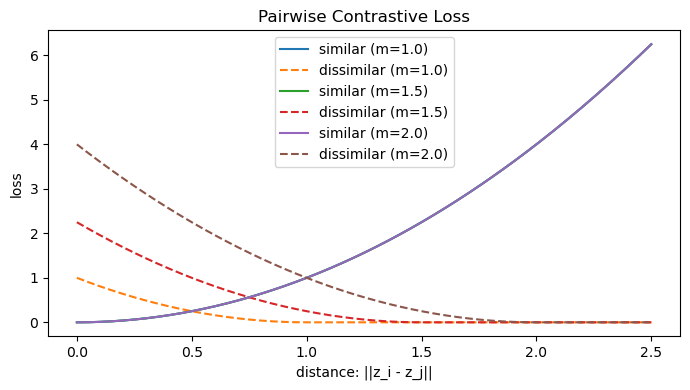

In [11]:
# --- Visualisation ---
if is_notebook():
    distances = torch.linspace(0, 2.5, 200)
    fig, ax = plt.subplots(figsize=(7, 4))

    zi = torch.zeros(len(distances), 1)  # (N, 1)
    zj = distances.unsqueeze(1)          # (N, 1)

    for m_val in [1.0, 1.5, 2.0]:
        sim_loss  = torch.tensor([
            contrastive_loss(zi[i:i+1], zj[i:i+1], torch.ones(1),  margin=m_val).item()
            for i in range(len(distances))
        ])
        diff_loss = torch.tensor([
            contrastive_loss(zi[i:i+1], zj[i:i+1], torch.zeros(1), margin=m_val).item()
            for i in range(len(distances))
        ])
        ax.plot(distances, sim_loss,  label=f"similar (m={m_val})")
        ax.plot(distances, diff_loss, '--', label=f"dissimilar (m={m_val})")

    ax.set_xlabel("distance: ||z_i - z_j||")
    ax.set_ylabel("loss")
    ax.set_title("Pairwise Contrastive Loss")
    ax.legend()
    plt.tight_layout()
    plt.show()

### 1.3  Triplet Loss

Given the embedding of a triplet $(\mathbf{z}, \mathbf{z}^+, \mathbf{z}^-)$:

$$\ell = \max\{0, \|\mathbf{z} - \mathbf{z}^+\|^2 - \|\mathbf{z} - \mathbf{z}^-\|^2 + m\}$$

Note that PyTorch's `nn.TripletMarginLoss` uses **raw** (non-squared) L2 distances by default, which differs from the formulation in the [original paper](https://openaccess.thecvf.com/content_cvpr_2015/html/Schroff_FaceNet_A_Unified_2015_CVPR_paper.html) (Schroff et al., 2015).

> Implement the triplet loss using **squared** L2 distances, as defined above.

In [12]:
# -------------- Task 1C: Defining Triplet Loss --------------
def triplet_loss(anchor: torch.Tensor, positive: torch.Tensor,
                 negative: torch.Tensor, margin: float = 0.3) -> torch.Tensor:
    """Triplet margin loss. 
    
    Args:
        anchor, positive, negative: embeddings of shape (B, D)
        margin: margin parameter
    Returns:
        trip_loss: Scalar mean loss.
    """
    # TODO:  implement triplet similarity from scratch
    pos_dist_sq = (anchor - positive).pow(2).sum(dim=-1)
    neg_dist_sq = (anchor - negative).pow(2).sum(dim=-1)
    trip_loss = F.relu(pos_dist_sq - neg_dist_sq + margin).mean()
    return trip_loss


In [16]:
if is_notebook():
    anchor = F.normalize(torch.randn(32, 128), dim=-1)
    pos    = F.normalize(torch.randn(32, 128), dim=-1)
    neg    = F.normalize(torch.randn(32, 128), dim=-1)

    ours = triplet_loss(anchor, pos, neg, margin=0.5)
    dist_sq = lambda x1, x2: F.pairwise_distance(x1, x2, p=2)**2
    ref  = nn.TripletMarginWithDistanceLoss(margin=0.5, distance_function=dist_sq)(anchor, pos, neg)
    assert torch.allclose(ours, ref, atol=1e-5), \
        f"Triplet loss mismatch: got {ours.item():.6f}, expected {ref.item():.6f} " \
        f"(abs diff = {(ours - ref).abs().item():.2e})"
    print(f"Our loss: {ours.item():.4f}  |  Reference: {ref.item():.4f}")
    print("Task 1C Passed!")

Our loss: 0.5131  |  Reference: 0.5131
Task 1C Passed!


---
## Task 2: SimCLR: Self-Supervised Learning

We will build a minimal [SimCLR](https://arxiv.org/pdf/2002.05709) pipeline following the steps below:
1. **Data augmentation:** serveral random views of each image.
2. **Encoder:** a small CNN backbone.
3. **Projection head:** an MLP that maps representations to the space where the contrastive loss is applied.
4. **InfoNCE (NT-Xent) training:** train on a large, unlabeled dataset.

After pre-training, we freeze the encoder and train a linear classifier to evaluate the learned representations.

<center>
<img src="simCLR.png" style="width: 60%;">
<figcaption>[Chen et al, ICML’20]<figcaption>
</center>

### 2.1  Data Augmentation
We need to prepare the data loading such that we sample two different, random augmentations for each image in the batch, called a **positive pair**. Check out [torchvision.transforms](https://docs.pytorch.org/vision/0.8/transforms.html). The easiest way to do this is by creating a stochastic transformation module that, when being called, performs a series of data augmentations to an image twice, including:
1. **Crop-and-resize:** crop a portion of the image and resize it back to the original size (`32x32`) with `scale=(0.2, 1.0)`
2. **Random horizontal flip:** Horizontally flip the image with a probability of `0.5`
3. **Colour distortion:** Apply color jitter with a probability of `0.5` for  brightness, contrast, and saturation; `0.2` for hue 
4. **Random grayscale:** Convert the image to grayscale with a probability of `0.2`
5. **Gaussian blur:** Apply gaussian blur with `kernel_size=3`

This is implemented in the class `SimCLRAugmentation` below:

In [17]:
# -------------- Task 2A: Defining Augmentation operations --------------
class SimCLRAugmentation:
    """Generate two augmented views of each image."""
    def __init__(self, size=32):
        self.transform = T.Compose([
            T.RandomResizedCrop(size, scale=(0.2, 1.0)),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomApply([
                T.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.2)
            ], p=0.5),
            T.RandomGrayscale(p=0.2),
            T.GaussianBlur(kernel_size=3),
        ] + _NORMALISE)

    def __call__(self, x):
        return self.transform(x), self.transform(x)

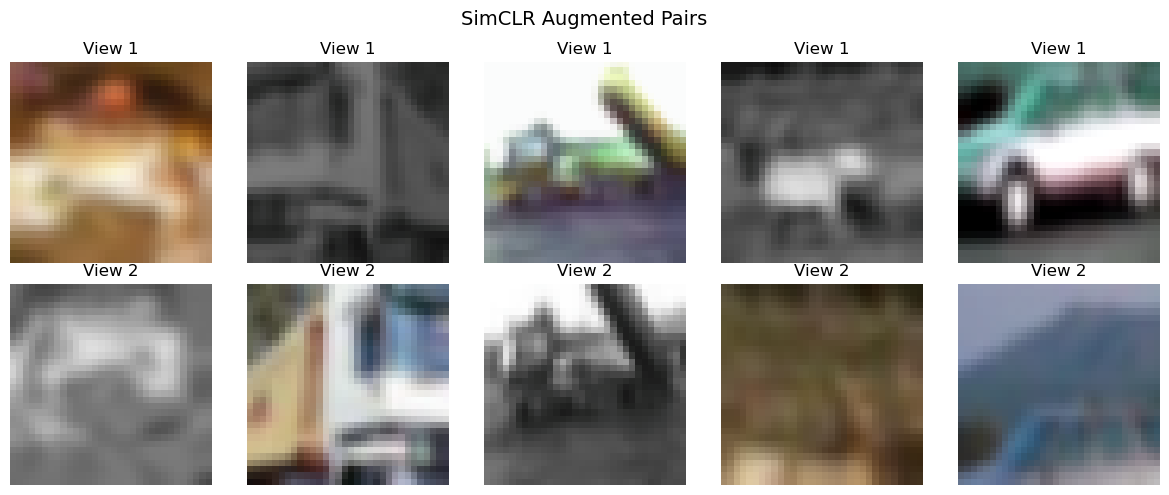

In [20]:
def unnorm(t):
    """Undo normalisation for display."""
    m = torch.tensor(CIFAR_MEAN).view(3, 1, 1).to(t.device)
    s = torch.tensor(CIFAR_STD).view(3, 1, 1).to(t.device)
    return (t * s + m).clamp(0, 1)
    
# Visualise augmented pairs
if is_notebook():
    aug = SimCLRAugmentation(size=32)
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for i in range(5):
        img, _ = train_data_raw[i]
        pil_img = T.ToPILImage()(img)
        v1, v2 = aug(pil_img)
        axes[0, i].imshow(unnorm(v1).permute(1, 2, 0))
        axes[1, i].imshow(unnorm(v2).permute(1, 2, 0))
        axes[0, i].set_title("View 1")
        axes[1, i].set_title("View 2")
        axes[0, i].axis("off")
        axes[1, i].axis("off")
    fig.suptitle("SimCLR Augmented Pairs", fontsize=14)
    plt.tight_layout()
    plt.show()

### 2.2  Encoder + Projection Head

The encoder backbone is a CNN that extracts features from images. The projection head is a simple MLP that maps the extracted features to the space where contrastive loss is computed — it is discarded after pre-training.

In [21]:
class ImageEncoder(nn.Module):
    """CNN encoder backbone for 32x32 CIFAR-10 images.

    Each stage contains exactly two `block`s (Conv-BN-ReLU) followed optionally by a MaxPool2d. 
    Within each stage:
      - The FIRST block changes the channel count (in_c -> out_c).
      - The SECOND block keeps the channel count the same (out_c -> out_c).
    A trailing MaxPool2d halves the spatial size when present.
    Stage 3 has no MaxPool — global average pooling reduces the spatial dims.
    Outputs raw (unnormalised) features.

    Shape summary:
                        channels    spatial   operation
    Input            (B,    3,      32, 32)
    stage1: block 1  (B,   32,      32, 32)   block(3,  32)
    stage1: block 2  (B,   32,      32, 32)   block(32, 32)
    stage1: pool     (B,   32,      16, 16)   MaxPool2d(2)
    stage2: block 1  (B,   64,      16, 16)   block(32, 64)
    stage2: block 2  (B,   64,      16, 16)   block(64, 64)
    stage2: pool     (B,   64,       8,  8)   MaxPool2d(2)
    stage3: block 1  (B,  128,       8,  8)   block(64, 128)
    stage3: block 2  (B,  128,       8,  8)   block(128, 128)
    gap              (B,  128,       1,  1)   AdaptiveAvgPool2d(1)
    flatten          (B,  128)
    fc               (B,  out_dim)

    Note: every conv layer in the encoder MUST come from the `block` helper defined below. 
    Do not introduce raw nn.Conv2d / nn.BatchNorm2d / nn.ReLU layers.
    """
    def __init__(self, out_dim: int = 64):
        super().__init__()

        def block(in_c, out_c):
            """Conv2d -> BatchNorm2d -> ReLU (preserves spatial size).

            The convolution uses a 3x3 kernel with padding=1, so H and W are unchanged; 
            only the channel count goes from in_c to out_c.
            """
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
            )

        # -------------- Task 2B: Define each stage --------------
        # TODO: Stage 1:    3 -> 32 channels, then halve 32x32 -> 16x16
        self.stage1 = nn.Sequential(
            block(3, 32),
            block(32, 32),
            nn.MaxPool2d(2),
        )
        # TODO: Stage 2:    32 -> 64 channels, then halve 16x16 -> 8x8
        self.stage2 = nn.Sequential(
            block(32, 64),
            block(64, 64),
            nn.MaxPool2d(2),
        )
        # TODO: Stage 3:    64 -> 128 channels, no pooling (gap handles it)
        self.stage3 = nn.Sequential(
            block(64, 128),
            block(128, 128),
        )

        self.gap     = nn.AdaptiveAvgPool2d(1)   # AdaptiveAvgPool2d(1):  (B, 128, 8, 8) -> (B, 128, 1, 1)
        self.flatten = nn.Flatten()              # Flatten:               (B, 128, 1, 1) -> (B, 128)
        self.fc      = nn.Linear(128, out_dim)   # Linear:                (B, 128)       -> (B, out_dim)
        self.out_dim = out_dim

    def forward(self, x):
        # -------------- Task 2C: Forward pass --------------
        # TODO: pass x through all stages
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.gap(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x


class SimCLRModel(nn.Module):
    """Encoder + projection head for SimCLR pre-training."""
    def __init__(self, feature_dim=64, proj_dim=32):
        super().__init__()
        # ImageEncoder as the encoder backbone
        self.encoder = ImageEncoder()
        # MLP Projection head ---
        self.projector = nn.Sequential(
            nn.Linear(self.encoder.out_dim, feature_dim),
            nn.ReLU(),
            nn.Linear(feature_dim, proj_dim),
        )
        
    def forward(self, x):
        h = self.encoder(x)                        # raw representation
        z = F.normalize(self.projector(h), dim=-1)  # normalised projection
        return h, z

In [22]:
if is_notebook():
    print("--- ImageEncoder tests ---")
    _enc = ImageEncoder(out_dim=64).to(device)
    _x = torch.randn(2, 3, 32, 32).to(device)
    _h = _enc(_x)

    assert _h.shape == (2, 64), \
        f"ImageEncoder output shape: expected (2, 64), got {tuple(_h.shape)}"

    # Check intermediate shapes by running stages individually
    with torch.no_grad():
        _s1 = _enc.stage1(_x)
        assert _s1.shape == (2, 32, 16, 16), \
            f"stage1 output: expected (2, 32, 16, 16), got {tuple(_s1.shape)}"
        _s2 = _enc.stage2(_s1)
        assert _s2.shape == (2, 64, 8, 8), \
            f"stage2 output: expected (2, 64, 8, 8), got {tuple(_s2.shape)}"
        _s3 = _enc.stage3(_s2)
        assert _s3.shape == (2, 128, 8, 8), \
            f"stage3 output: expected (2, 128, 8, 8), got {tuple(_s3.shape)}"

    print("ImageEncoder tests passed!")
    del _enc, _x, _h, _s1, _s2, _s3

    print("--- SimCLRModel tests ---")
    _model = SimCLRModel(feature_dim=128, proj_dim=64).to(device)
    _x = torch.randn(4, 3, 32, 32).to(device)
    _h, _z = _model(_x)

    # Output shapes
    assert _h.shape == (4, _model.encoder.out_dim), \
        f"Representation shape: expected (4, {_model.encoder.out_dim}), got {tuple(_h.shape)}"
    assert _z.shape == (4, 64), \
        f"Projection shape: expected (4, 64), got {tuple(_z.shape)}"

    # Projection should be L2-normalised (each row has unit norm)
    norms = _z.norm(dim=-1)
    assert torch.allclose(norms, torch.ones_like(norms), atol=1e-5), \
        f"Projections should be unit-normalised, got norms: {norms}"

    # Representation should NOT be normalised (raw features)
    h_norms = _h.norm(dim=-1)
    assert not torch.allclose(h_norms, torch.ones_like(h_norms), atol=1e-2), \
        "Representations should be raw (unnormalised) — did you normalise too early?"

    n_simclr = sum(p.numel() for p in _model.parameters())
    n_enc    = sum(p.numel() for p in _model.encoder.parameters())
    n_proj   = sum(p.numel() for p in _model.projector.parameters())
    print(f"SimCLR total: {n_simclr:,}  (encoder: {n_enc:,} + projector: {n_proj:,})")
    assert n_simclr == n_enc + n_proj, \
        "Total params should equal encoder + projector (no extra parameters)"

    print("SimCLRModel tests passed!")
    del _model, _x, _h, _z

--- ImageEncoder tests ---
ImageEncoder tests passed!
--- SimCLRModel tests ---
SimCLR total: 312,288  (encoder: 295,712 + projector: 16,576)
SimCLRModel tests passed!


**Q2.2:** The projection head is discarded after pre-training — we keep only the encoder. Chen et al. (2020) showed that downstream accuracy is *higher* when using encoder features than projection features. Why might the projection head hurt downstream performance?

The projection head is trained specifically to make the contrastive objective easy to optimise, not to preserve all information that may be useful for downstream tasks. In practice it often throws away details such as class-discriminative cues, fine texture, or spatial information, because those details are not needed once the model has learned augmentation-invariant matching.

The encoder features are usually richer and more general-purpose, while the projection features are more specialised to the NT-Xent loss. So keeping only the encoder gives a representation that transfers better to new tasks.

### 2.3  NT-Xent (Normalized Temperature-Scaled Cross-Entropy) Loss

For a batch of $B$ images producing $2B$ augmented views, each image $i$ has exactly one positive (its other view) among $2B - 1$ negatives.

$$l_{ij} = -\log \frac{\exp(\text{sim}(z_i, z_j) / \tau)}{\sum_{k=1}^{2N} \mathbb{1}_{[k \neq i]} \exp(\text{sim}(z_i, z_k) / \tau)} $$

where cosine similarity (defined in Task 1.1) is used as the similarity metric.

> Complete the NT-Xent loss. 

In [23]:
# -------------- Task 2D: Defining NT-Xent Loss --------------
def nt_xent_loss(z1: torch.Tensor, z2: torch.Tensor,
                 temperature: float = 0.5) -> torch.Tensor:
    """NT-Xent loss for SimCLR.
    
    Args:
        z1, z2: normalised projections from the two views, shape (B, D)
        temperature: temperature scaling
    Returns:
        loss: Scalar loss.
    """
    B = z1.shape[0]
    z = torch.cat([z1, z2], dim=0)  # (2B, D)
    
    # TODO: 
    # 1. All-pairs cosine similarity (2B, 2B), scaled by temperature
    # 2. Mask out self-similarity (diagonal) by setting an infinitely small number 
    # so that it contributes nothing when going through softmax
    # 3. Positive is at index (i+B) % 2B
    # i.e. (i, i+B) and (i+B, i)
    # 4. Cross-entropy loss with mean reduction
    logits = (z @ z.T) / temperature
    self_mask = torch.eye(2 * B, device=z.device, dtype=torch.bool)
    logits = logits.masked_fill(self_mask, -1e9)
    targets = (torch.arange(2 * B, device=z.device) + B) % (2 * B)

    return F.cross_entropy(logits, targets)

In [24]:
if is_notebook():
    import math
    # Test 1: output is a scalar tensor
    z1_t = F.normalize(torch.randn(4, 16), dim=-1).to(device)
    z2_t = F.normalize(torch.randn(4, 16), dim=-1).to(device)
    assert nt_xent_loss(z1_t, z2_t).shape == torch.Size([]), \
        "nt_xent_loss should return a scalar"

    expected_loss = math.log(1 + 2 / math.e)          # ≈ 0.5514
    z_orth = torch.eye(2, 2).to(device)     # [[1,0],[0,1]]
    z_orh_cln = z_orth.clone().to(device)
    loss_perfect = nt_xent_loss(z_orth, z_orh_cln, temperature=1.0)
    assert abs(loss_perfect.item() - expected_loss) < 1e-4, \
        f"Perfect pairs: expected {expected_loss:.5f}, got {loss_perfect.item():.5f}"

    # Test 3: lower temperature → lower loss
    loss_low_t  = nt_xent_loss(z_orth, z_orh_cln, temperature=0.5)
    loss_high_t = nt_xent_loss(z_orth, z_orh_cln, temperature=2.0)
    assert loss_low_t < loss_high_t, \
        "Lower temperature should give lower loss when positives dominate"

    print("Task 2D Passed!")
    print(f"  Test 1 — output shape:          {nt_xent_loss(z1_t, z2_t).shape}")
    print(f"  Test 2 — perfect pairs (T=1.0): {loss_perfect.item():.5f}  (expected {expected_loss:.5f})")
    print(f"  Test 3 — T=0.5: {loss_low_t.item():.5f}  <  T=2.0: {loss_high_t.item():.5f}")

Task 2D Passed!
  Test 1 — output shape:          torch.Size([])
  Test 2 — perfect pairs (T=1.0): 0.55144  (expected 0.55144)
  Test 3 — T=0.5: 0.23954  <  T=2.0: 0.79438


**Q2.3:** The name "NT-Xent" stands for Normalized Temperature-scaled Cross-Entropy. Explain what each word refers to in the formula.

1. **Normalized:** the projected vectors are L2-normalised before the loss is computed, so similarity is based on direction rather than raw magnitude.
2. **Temperature-scaled:** the logits are divided by the temperature $\tau$, which controls how sharp or soft the softmax distribution is.
3. **Cross-Entropy:** for each anchor, the loss treats its matching augmented view as the correct class and all other views in the batch as competing classes, then applies a cross-entropy objective.

### 2.4  Pre-Training

We define a reusable training function `train_simclr_variant` that takes an augmentation class and trains a fresh SimCLR model end-to-end. The function returns a dictionary with:
- the trained `model`
- the per-epoch `losses`
- the encoder features `feats` on the bank (already L2-normalised)
- two diagnostic scalars: `emb_var` (mean per-dimension variance — drops to ~0 if the model collapses) and `sim_gap` (same-class minus different-class similarity — should be positive)

Before training begins, we snapshot the embeddings of 500 test images at random initialisation — these will serve as our baseline. After training, we snapshot them again. Both sets will be used for the t-SNE comparison in Task 3. Expect training to take around 10 minutes on a MacBook Pro (M3 chip), so now's a good time for a coffee break!

In [25]:
def sim_distributions(h):
    """Split all pairwise cosine similarities into same-class and different-class groups.

    Args:
        h: feature matrix, shape (BANK_SIZE, D). Need not be unit-normalised.

    Returns:
        same_sims (np.ndarray): cosine similarities for all same-class pairs (no diagonal).
        diff_sims (np.ndarray): cosine similarities for all cross-class pairs.
    """
    feats = F.normalize(h, dim=-1)
    sim_matrix = feats @ feats.T
    label_eq  = (bank_labels.unsqueeze(0) == bank_labels.unsqueeze(1))
    diag_mask = ~torch.eye(BANK_SIZE, dtype=torch.bool)
    same_sims = sim_matrix[label_eq & diag_mask].numpy()
    diff_sims = sim_matrix[~label_eq].numpy()
    return same_sims, diff_sims
    

def train_simclr_variant(aug_class, label, n_epochs=20, temperature=0.3):
    """Train a SimCLR model with a given augmentation and return diagnostics.

    Args:
        aug_class: callable (no args) that returns a torchvision transform.
                   Must produce pairs (x1, x2) when called on an image.
        label:     short string used for the tqdm progress bar and result dict.
        n_epochs:  number of training epochs.
        temperature: NT-Xent temperature.

    Returns:
        dict with keys: label, losses, feats, h_random, h_trained, emb_var, sim_gap, model
    """
    ds = torchvision.datasets.CIFAR10(
        root=DATA_ROOT, train=True, download=False, transform=aug_class()
    )
    loader = DataLoader(
        torch.utils.data.Subset(ds, torch.randperm(len(ds))[:SUBSET_SIZE]),
        batch_size=256, shuffle=True, num_workers=0, drop_last=True
    )
    mdl = SimCLRModel(feature_dim=64, proj_dim=32).to(device)
    opt = torch.optim.Adam(mdl.parameters(), lr=3e-3, fused=True)

    # Snapshot BEFORE training (random init) on the shared bank
    mdl.eval()
    with torch.no_grad():
        h_random, _ = mdl(bank_tensors.to(device))
        h_random = h_random.cpu()

    losses = []
    pbar = tqdm(range(n_epochs), desc=label)
    for epoch in pbar:
        mdl.train()
        epoch_loss = 0.0
        for (x1, x2), _ in loader:
            x1, x2 = x1.to(device), x2.to(device)
            _, z1 = mdl(x1)
            _, z2 = mdl(x2)
            loss = nt_xent_loss(z1, z2, temperature=temperature)
            opt.zero_grad()
            loss.backward()
            opt.step()
            epoch_loss += loss.item()
        avg = epoch_loss / len(loader)
        losses.append(avg)
        pbar.set_postfix(loss=f"{avg:.3f}")

    # Snapshot AFTER training
    mdl.eval()
    with torch.no_grad():
        h_trained, _ = mdl(bank_tensors.to(device))
        h_trained = h_trained.cpu()
        feats = F.normalize(h_trained, dim=-1)

    same, diff = sim_distributions(h_trained)
    emb_var = feats.var(dim=0).mean().item()
    sim_gap = same.mean() - diff.mean()

    return {
        "label": label,
        "losses": losses,
        "feats": feats,
        "h_random": h_random,
        "h_trained": h_trained,
        "emb_var": emb_var,
        "sim_gap": sim_gap,
        "model": mdl,
    }

In [46]:
NUM_EPOCHS = 20

if is_notebook():
    full_aug_result = train_simclr_variant(SimCLRAugmentation, "SimCLR (full aug)",
                                            n_epochs=NUM_EPOCHS)

    # Unpack into the variable names used throughout the rest of the notebook
    simclr_model  = full_aug_result["model"]
    simclr_losses = full_aug_result["losses"]
    h_random      = full_aug_result["h_random"]
    h_simclr      = full_aug_result["h_trained"]

    n_simclr_params = sum(p.numel() for p in simclr_model.parameters())
    print(f"Number of parameters in SimCLR Model: {n_simclr_params:,}")
    print(f"Final loss: {simclr_losses[-1]:.4f}  |  "
          f"emb_var: {full_aug_result['emb_var']:.4f}  |  "
          f"sim_gap: {full_aug_result['sim_gap']:+.3f}")

    plt.plot(simclr_losses, 'o-', markersize=3)
    plt.xlabel("Epoch")
    plt.ylabel("NT-Xent Loss")
    plt.title("SimCLR Pre-Training Loss")
    plt.show()

SimCLR (full aug):   0%|          | 0/20 [00:00<?, ?it/s]

KeyboardInterrupt: 

### 2.5  Linear Evaluation

We freeze the encoder backbone and train a simple linear classifier on top. If the contrastive representations are good, even a linear probe should achieve reasonable accuracy.

In [26]:
def extract_features(model, dataset, max_samples=5000):
    """
    Extract encoder representations from a normalised dataset.

    Args:
        model: freezed model
        dataset: train dataset
    Returns:
        feats: extracted features of dataset samples
        labels: corresponding labels of dataset samples
    """
    loader = DataLoader(dataset, batch_size=256, shuffle=False)
    feats, labels = [], []
    model.eval()
    with torch.no_grad():
        for x, y in tqdm(loader, desc="Extracting features", leave=False):
            # -------------- Task 2E: Linear Probing --------------
            # TODO: Extract representation from pre-trained encoder
            # Append extracted features and real labels to returned lists
            h = model.encoder(x.to(device)).cpu()
            feats.append(h)
            labels.append(y.cpu())
            
            if sum(f.shape[0] for f in feats) >= max_samples:
                break
    return torch.cat(feats)[:max_samples], torch.cat(labels)[:max_samples]

In [29]:
if is_notebook():
    train_feats, train_labels = extract_features(simclr_model, train_data, max_samples=5000)
    test_feats, test_labels   = extract_features(simclr_model, test_data, max_samples=2000)

    linear_clf = nn.Linear(simclr_model.encoder.out_dim, 10).to(device)
    opt = torch.optim.Adam(linear_clf.parameters(), lr=3e-3)

    pbar = tqdm(range(NUM_EPOCHS), desc="Linear probe")
    for ep in pbar:
        logits = linear_clf(train_feats.to(device))
        loss = F.cross_entropy(logits, train_labels.to(device))
        opt.zero_grad()
        loss.backward()
        opt.step()

        with torch.no_grad():
            acc = (logits.argmax(dim=-1).cpu() == train_labels).float().mean()
        pbar.set_postfix(loss=f"{loss.item():.3f}", train_acc=f"{acc:.1%}")

    with torch.no_grad():
        preds = linear_clf(test_feats.to(device)).argmax(dim=-1).cpu()
        probe_acc = (preds == test_labels).float().mean()
    print(f"Linear probe accuracy: {probe_acc:.1%}  (random baseline = 10%)")

NameError: name 'simclr_model' is not defined

**Q2.5:** We evaluate with a *linear* probe rather than a fine-tuned MLP or full network. What is the reasoning behind this choice? What would be wrong with using a powerful non-linear classifier?

A linear probe tests whether the learned representation is already linearly separable. That makes it a clean way to measure the quality of the encoder itself, rather than the power of the classifier placed on top of it.

If we used a strong non-linear classifier, it could compensate for weak features by learning a complicated decision boundary. Then high downstream accuracy would no longer mean that the SimCLR representation is good; it could just mean the probe is powerful enough to fix a poor embedding.


---
## Task 3: Into the Embedding Space

Now that SimCLR is trained, let's explore *what it actually learned* by poking around in the embedding space. We'll compare representations from three sources:

1. **Random init** — the encoder before any training (captured in Task 2.4)
2. **SimCLR** — the encoder after contrastive training
3. **Autoencoder** — a reconstruction-based baseline trained on the same data

### 3.1  Autoencoder Baseline

The autoencoder uses the *same* `ImageEncoder` architecture as SimCLR, but trains it to reconstruct pixels.

In [30]:
class SmallAutoencoder(nn.Module):
    """Encoder-decoder for 32×32 CIFAR images.

    The encoder bottleneck vector is the learned representation.
    The decoder mirrors the encoder in reverse, upsampling back to 32×32.

    Encoder: ImageEncoder with out_dim = bottleneck_dim.

    Decoder shape summary:
                            channels   spatial    operation
    z / bottleneck    (B,   64)
    decoder_fc        (B,  128,        4,   4)     Linear(64 -> 128*4*4) + Unflatten(128, 4, 4)
    dec_stage1        (B,   64,        8,   8)     block(128, 64)                              # 4x4 -> 8x8
    dec_stage2        (B,   32,       16,  16)     block(64,  32)                              # 8x8 -> 16x16
    dec_stage3        (B,    3,       32,  32)     ConvTranspose2d(32, 3) + Sigmoid            # 16x16 -> 32x32

    Channel rule: each `block` call halves the channel count (in_c -> in_c/2) and doubles the spatial size. 
    The output stage drops to 3 channels for RGB and uses Sigmoid instead of BatchNorm+ReLU because pixel values are in [0, 1].

    """
    def __init__(self, bottleneck_dim=64):
        super().__init__()

        def block(in_c, out_c):
            """ConvTranspose2d -> BatchNorm2d -> ReLU.

            Uses kernel_size=4, stride=2, padding=1, which DOUBLES the spatial size. 
            Channel count goes from in_c to out_c.
            """
            return nn.Sequential(
                nn.ConvTranspose2d(in_c, out_c, 4, stride=2, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(),
            )

        # -------------- Task 3A: Defining Encoder and Decoder --------------
        # TODO: use ImageEncoder with `out_dim` set to `bottleneck_dim`
        self.encoder = ImageEncoder(out_dim=bottleneck_dim)

        # TODO: Project the bottleneck back into a spatial feature map so we
        #       can start decoding. The Linear layer maps (B, bottleneck_dim)
        #       to (B, 128 * 4 * 4); Unflatten reshapes to (B, 128, 4, 4).
        self.decoder_fc = nn.Sequential(
            nn.Linear(bottleneck_dim, 128 * 4 * 4),
            nn.Unflatten(1, (128, 4, 4)),
        )

        # TODO: dec_stage1 — block(128, 64), spatial 4x4 -> 8x8
        self.dec_stage1 = block(128, 64)
        # TODO: dec_stage2 — block(64, 32), spatial 8x8 -> 16x16
        self.dec_stage2 = block(64, 32)
        # TODO: dec_stage3: spatial 16x16 -> 32x32
        # Use a single nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1)
        # followed by nn.Sigmoid(). 
        self.dec_stage3 = nn.Sequential(
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        # TODO: Compute the bottleneck representation z, then run it through
        #       decoder_fc, dec_stage1, dec_stage2, dec_stage3 to produce the reconstructed image. 
        #       Return BOTH z and the reconstruction.
        z = self.encoder(x)
        out = self.decoder_fc(z)
        out = self.dec_stage1(out)
        out = self.dec_stage2(out)
        out = self.dec_stage3(out)
        return z, out

In [31]:
if is_notebook():
    print("--- SmallAutoencoder tests ---")
    _ae = SmallAutoencoder(bottleneck_dim=64).to(device)
    _x = torch.randn(4, 3, 32, 32).to(device)
    _z, _recon = _ae(_x)

    # Bottleneck shape
    assert _z.shape == (4, 64), \
        f"Bottleneck shape: expected (4, 64), got {tuple(_z.shape)}"

    # Reconstruction matches input spatial dimensions
    assert _recon.shape == (4, 3, 32, 32), \
        f"Reconstruction shape: expected (4, 3, 32, 32), got {tuple(_recon.shape)}"

    # Sigmoid output → values in [0, 1]
    assert _recon.min() >= 0.0 and _recon.max() <= 1.0, \
        f"Reconstruction should be in [0, 1] (Sigmoid), got [{_recon.min():.3f}, {_recon.max():.3f}]"

    # Encoder is shared with ImageEncoder (same architecture)
    assert isinstance(_ae.encoder, ImageEncoder), \
        f"Autoencoder encoder should be ImageEncoder, got {type(_ae.encoder).__name__}"

    # Decoder intermediate shapes
    with torch.no_grad():
        _fc_out = _ae.decoder_fc(_z)
        assert _fc_out.shape == (4, 128, 4, 4), \
            f"decoder_fc output: expected (4, 128, 4, 4), got {tuple(_fc_out.shape)}"
        _d1 = _ae.dec_stage1(_fc_out)
        assert _d1.shape == (4, 64, 8, 8), \
            f"dec_stage1 output: expected (4, 64, 8, 8), got {tuple(_d1.shape)}"
        _d2 = _ae.dec_stage2(_d1)
        assert _d2.shape == (4, 32, 16, 16), \
            f"dec_stage2 output: expected (4, 32, 16, 16), got {tuple(_d2.shape)}"

    n_ae = sum(p.numel() for p in _ae.parameters())
    n_ae_enc = sum(p.numel() for p in _ae.encoder.parameters())
    n_ae_dec = n_ae - n_ae_enc
    print(f"Autoencoder total: {n_ae:,}  (encoder: {n_ae_enc:,} + decoder: {n_ae_dec:,})")

    print("SmallAutoencoder tests passed!")
    del _ae, _x, _z, _recon, _fc_out, _d1, _d2

--- SmallAutoencoder tests ---
Autoencoder total: 594,499  (encoder: 295,712 + decoder: 298,787)
SmallAutoencoder tests passed!


In [32]:
if is_notebook():
    ae_loader = DataLoader(
        torch.utils.data.Subset(train_data,
            torch.randperm(len(train_data))[:SUBSET_SIZE]),
        batch_size=256, shuffle=True, num_workers=0, drop_last=True
    )
    ae = SmallAutoencoder(bottleneck_dim=64).to(device)
    n_ae_params = sum(p.numel() for p in ae.parameters())
    print("Number of parameters in Autoencoder: ", n_ae_params)
    
    ae_opt = torch.optim.Adam(ae.parameters(), lr=3e-3, fused=True)
    ae_losses = []

    pbar = tqdm(range(NUM_EPOCHS), desc="Autoencoder")
    for epoch in pbar:
        epoch_loss = 0.0
        for x, _ in ae_loader:
            x = x.to(device)
            z, x_hat = ae(x)
            loss = F.mse_loss(x_hat, unnorm(x))
            ae_opt.zero_grad()
            loss.backward()
            ae_opt.step()
            epoch_loss += loss.item()
        avg = epoch_loss / len(ae_loader)
        ae_losses.append(avg)
        pbar.set_postfix(loss=f"{avg:.4f}")

    ae.eval()
    with torch.no_grad():
        h_ae = ae.encoder(bank_tensors.to(device)).cpu()
    print("Autoencoder trained")

Number of parameters in Autoencoder:  594499


Autoencoder:   0%|          | 0/20 [00:00<?, ?it/s]

KeyboardInterrupt: 

### 3.2  T-SNE Comparison

T-SNE projects high-dimensional embeddings down to 2D while preserving local neighbourhood structure. All three representations are embedded from the **same 500 test images**. The only difference is how the encoder was trained (or not trained). Colours are ground-truth class labels — none of these models ever saw labels during training.

In [43]:
if is_notebook():
    # Compute t-SNE for all three
    print("Running t-SNE ...")
    coords_random = TSNE(n_components=2, perplexity=30, random_state=random_seed).fit_transform(h_random.numpy())
    coords_ae     = TSNE(n_components=2, perplexity=30, random_state=random_seed).fit_transform(h_ae.numpy())
    coords_simclr = TSNE(n_components=2, perplexity=30, random_state=random_seed).fit_transform(h_simclr.numpy())

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    titles = ["Random Init", "Autoencoder (reconstruction)", "SimCLR (contrastive)"]
    all_coords = [coords_random, coords_ae, coords_simclr]

    for ax, coords, title in zip(axes, all_coords, titles):
        scatter = ax.scatter(coords[:, 0], coords[:, 1],
                             c=bank_labels.numpy(), cmap='tab10',
                             alpha=0.6, s=12)
        ax.set_title(title, fontsize=13)
        ax.set_xticks([])
        ax.set_yticks([])

    cbar = plt.colorbar(scatter, ax=axes, ticks=range(10), shrink=0.8, pad=0.02, location='bottom')
    cbar.ax.set_xticklabels(CIFAR10_CLASSES)
    plt.suptitle("Representation Quality: Random vs Reconstruction vs Contrastive",
                 fontsize=14, y=1.02)
    plt.show()

Running t-SNE ...


NameError: name 'h_random' is not defined

**Q3.2:** Compare the three panels.
1. Does the random-init embedding show any class structure? Why or why not?
2. SimCLR is trained to be *invariant to augmentations* (crop, flip, colour). The autoencoder is trained to *reconstruct pixels*. How should this difference show up in the clusters? Which model do you expect to group a red car near a red truck, and why?
3. Look at specific class pairs: do "automobile" and "truck" overlap more in one model than the other? What about "cat" and "dog"?

1. The random-init embedding should show little or no clear class structure. With random weights, the encoder has not learned meaningful semantic features, so distances mostly reflect accidental responses of the untrained filters rather than object category.
2. SimCLR should form clusters based more on semantic content, because it is rewarded for ignoring crop, flip, and colour changes. The autoencoder should be more sensitive to low-level appearance, because it must preserve pixel-level detail to reconstruct the image. For that reason, an autoencoder is more likely to place a red car near a red truck if they share similar colour, texture, or background, while SimCLR is more likely to group cars with other cars even when colour changes.
3. I would expect **automobile** and **truck** to overlap more in the autoencoder features, since both classes can look visually similar at the pixel level. In SimCLR they may still be close, but the clustering is usually cleaner. For **cat** and **dog**, both models can show some overlap because they are visually and semantically similar, but SimCLR should still do a better job of organising them by higher-level object identity rather than just fur texture or colour.

### 3.3  Nearest-Neighbour Retrieval

Pick a query image and find the $k$ nearest and $k$ furthest images in the embedding space (check out [torch.topk](https://docs.pytorch.org/docs/stable/generated/torch.topk.html)). This reveals what the model considers "similar" and "dissimilar".

In [44]:
def retrieve(query_idx: int, feats: torch.Tensor, k: int = 5):
    """Return the k nearest and k furthest images to a query in embedding space.
    The query image itself is excluded from the nearest results

    Args:
        query_idx: index of the query image in the feature bank.
        feats:     L2-normalised feature matrix, shape (N, D).
        k:         number of neighbours to return.

    Returns:
        nearest  (np.ndarray):   indices of the k most   similar images, shape (k,).
        furthest (np.ndarray):   indices of the k least  similar images, shape (k,).
        sims (torch.Tensor):     cosine similarity of every bank image to the query,
                                 shape (N,).  Index with sims[idx] to get a score.
    """
    # -------------- Task 3B --------------
    # TODO
    sims = feats @ feats[query_idx]  # (N,)
    nearest_sims = sims.clone()
    nearest_sims[query_idx] = -torch.inf
    nearest = torch.topk(nearest_sims, k=k).indices.cpu().numpy()
    furthest = torch.topk(sims, k=k, largest=False).indices.cpu().numpy()

    return nearest, furthest, sims

In [45]:
def show_retrieval(query_idx, nearest, furthest, sims, k=5, title=""):
    """Plot query image alongside k nearest and k furthest neighbours.

    Args:
        query_idx: index of the query image in the feature bank
        nearest:   numpy array of k nearest-neighbour bank indices
        furthest:  numpy array of k furthest-neighbour bank indices
        sims:      cosine-similarity vector for the query (shape N,)
        k:         number of neighbours shown per row
        title:     optional suptitle (e.g. model name)
    """
    fig, axes = plt.subplots(2, k + 1, figsize=(2.2 * (k + 1), 5))
    if title:
        fig.suptitle(title, fontsize=12, fontweight='bold', y=1.01)

    for row in range(2):
        axes[row, 0].imshow(bank_imgs_raw[query_idx].permute(1, 2, 0))
        axes[row, 0].set_title(
            f"QUERY\n{CIFAR10_CLASSES[bank_labels[query_idx]]}",
            fontweight='bold', fontsize=9)
        axes[row, 0].axis("off")

    for col, idx in enumerate(nearest):
        axes[0, col + 1].imshow(bank_imgs_raw[idx].permute(1, 2, 0))
        axes[0, col + 1].set_title(
            f"{CIFAR10_CLASSES[bank_labels[idx]]}\nsim={sims[idx]:.2f}", fontsize=8)
        axes[0, col + 1].axis("off")

    for col, idx in enumerate(furthest):
        axes[1, col + 1].imshow(bank_imgs_raw[idx].permute(1, 2, 0))
        axes[1, col + 1].set_title(
            f"{CIFAR10_CLASSES[bank_labels[idx]]}\nsim={sims[idx]:.2f}", fontsize=8)
        axes[1, col + 1].axis("off")

    axes[0, 0].annotate("Nearest",  xy=(-0.05, 0.5), xycoords="axes fraction",
                        ha='right', va='center', fontsize=10)
    axes[1, 0].annotate("Furthest", xy=(-0.05, 0.5), xycoords="axes fraction",
                        ha='right', va='center', fontsize=10)
    plt.tight_layout()
    plt.show()


if is_notebook():
    K = 5
    retrieval_queries = torch.randint(0, BANK_SIZE, (K,))

    simclr_feats_norm = F.normalize(h_simclr, dim=-1)
    ae_feats_norm     = F.normalize(h_ae, dim=-1)

    for qi in retrieval_queries:
        qi = qi.item()
        print(f"\n{'='*50}")
        print(f"Query idx {qi}: {CIFAR10_CLASSES[bank_labels[qi]]}")
        print(f"{'='*50}")

        for feats_norm, tag in [
            (ae_feats_norm,     "Autoencoder"),
            (simclr_feats_norm, "SimCLR"),
        ]:
            nearest, furthest, sims = retrieve(qi, feats_norm, k=K)
            show_retrieval(qi, nearest, furthest, sims, k=K, title=tag)

NameError: name 'h_simclr' is not defined

**Q3.3:** Find a query where SimCLR and the autoencoder retrieve *different* nearest neighbours. What does each model seem to prioritise — semantic category, colour, texture, shape?

When the two models disagree, SimCLR usually prioritises **semantic category and overall object shape**: for example, a car query tends to retrieve other cars even if they have different colours or backgrounds. The autoencoder usually prioritises **low-level appearance** such as colour, texture, brightness, and background patterns, because those are directly useful for reconstruction.

So if a query image has a distinctive colour or texture, the autoencoder may retrieve visually similar but semantically different images, while SimCLR is more likely to retrieve semantically matching neighbours.

### 3.4  Similarity Distribution

Plot the distribution of cosine similarities for *same-class* pairs vs *different-class* pairs. A well-trained contrastive model should separate these two distributions.

In [ ]:
if is_notebook():
    groups = [
        ("Random init",  h_random),
        ("Autoencoder",  h_ae),
        ("SimCLR",       h_simclr),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
    for ax, (title, h) in zip(axes, groups):
        same_sims, diff_sims = sim_distributions(h)
        ax.hist(diff_sims,  bins=60, alpha=0.6, density=True, label="diff class",  color="steelblue")
        ax.hist(same_sims,  bins=60, alpha=0.6, density=True, label="same class",  color="tomato")
        gap = same_sims.mean() - diff_sims.mean()
        ax.set_title(f"{title}\ngap = {gap:+.3f}")
        ax.set_xlabel("Cosine similarity")
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)
    plt.suptitle("Same-class vs Different-class Cosine Similarity", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"{'Model':<14} {'same':>7} {'diff':>7} {'gap':>7}")
    print("-" * 40)
    for title, h in groups:
        s, d = sim_distributions(h)
        print(f"{title:<14} {s.mean():>7.3f} {d.mean():>7.3f} {s.mean()-d.mean():>+7.3f}")

**Q3.4:** Look at the overlap between the two distributions. What would this plot look like in two extreme cases: (a) a *perfect* model where same-class images are always more similar than different-class images, and (b) a *collapsed* model where every input maps to the same point?

1. In a **perfect** model, the two histograms would be completely separated: same-class similarities would be concentrated far to the right, different-class similarities far to the left, with essentially no overlap.
2. In a **collapsed** model, every image would have the same embedding, so every cosine similarity would be the same value. After normalisation, that value would be 1 for all pairs. The two distributions would therefore lie on top of each other as the same sharp spike, and the similarity gap would be 0.

---
## Task 4: Observing Collapse

Contrastive learning risks **representation collapse** — the model maps every input to the same point. The lecture (slide 12) lists several prevention techniques: feature normalisation, negative sampling, EMA, **strong data augmentation**, and projection heads.

In this task we systematically remove augmentations to observe how representations degrade.

### 4.1  Augmentation Ablation

We define three augmentation regimes, from strongest to weakest:

| Variant | Augmentations | What changes between two views |
|---|---|---|
| **Full** | crop + flip + colour jitter + grayscale | position, orientation, colours |
| **Spatial only** | crop + flip (no colour augmentation) | position, orientation |
| **Identity** | normalise only — both views are identical | nothing |

For each, we train a SimCLR model with the same architecture, data, and hyperparameters, then measure two diagnostics:
- **Embedding variance** — how spread out are the representations? (collapsed = near-zero)
- **Similarity gap** — mean same-class sim minus mean diff-class sim (collapsed = near-zero)

In [41]:
# -------------- Task 4A: Defining SpatialOnlyAugmentation --------------
class SpatialOnlyAugmentation:
    """Crop + flip, no colour augmentation."""
    def __init__(self, size=32):
        self.transform = T.Compose([
            T.RandomResizedCrop(size, scale=(0.2, 1.0)),
            T.RandomHorizontalFlip(p=0.5),
        ] + _NORMALISE)
    def __call__(self, x):
        return self.transform(x), self.transform(x)


# -------------- Task 4B: Defining IdentityAugmentation --------------
class IdentityAugmentation:
    """No augmentation — both views are the same image."""
    def __init__(self):
        # TODO: Normalization only
        self.transform = T.Compose(_NORMALISE)
    def __call__(self, x):
        t = self.transform(x)
        return t, t.clone()

In [42]:
if is_notebook():
    # train the new variant and reuse full-augmentation result from Task 2.4
    spatial_only_result = train_simclr_variant(SpatialOnlyAugmentation, "Spatial only",
                                                n_epochs=NUM_EPOCHS)
    no_aug_result       = train_simclr_variant(IdentityAugmentation, "No augmentation",
                                                n_epochs=NUM_EPOCHS)
    ablation_results = [
        {**full_aug_result, "label": "Full augmentation"},
        spatial_only_result,
        no_aug_result,
    ]
    print(f"\n{'Variant':<22} {'emb_var':>10} {'sim_gap':>10}")
    print("-" * 44)
    for r in ablation_results:
        print(f"  {r['label']:<20} {r['emb_var']:>10.4f} {r['sim_gap']:>+10.3f}")

Spatial only:   0%|          | 0/20 [00:00<?, ?it/s]

KeyboardInterrupt: 

### 4.2  Ablation Results

In [ ]:
if is_notebook():
    labels = [r["label"] for r in ablation_results]
    vars_  = [r["emb_var"] for r in ablation_results]
    gaps   = [r["sim_gap"] for r in ablation_results]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
    colors = ['#88cc88', '#cccc66', '#cc6666']

    bars1 = ax1.bar(labels, vars_, color=colors)
    ax1.set_ylabel("Mean per-dim variance")
    ax1.set_title("Embedding Variance")
    for bar, v in zip(bars1, vars_):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                 f"{v:.4f}", ha='center', fontsize=9)

    bars2 = ax2.bar(labels, gaps, color=colors)
    ax2.set_ylabel("Same-class sim − diff-class sim")
    ax2.set_title("Similarity Gap")
    ax2.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    for bar, g in zip(bars2, gaps):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f"{g:.3f}", ha='center', fontsize=9)

    plt.suptitle("Augmentation Ablation",
                 fontsize=13)
    plt.tight_layout()
    plt.show()

    # Loss curves
    fig, ax = plt.subplots(figsize=(7, 4))
    for r, c in zip(ablation_results, colors):
        ax.plot(r["losses"], 'o-', label=r["label"], color=c)
    ax.set_xlabel("Epoch"); ax.set_ylabel("NT-Xent Loss")
    ax.set_title("Loss Curves Across Augmentation Regimes")
    ax.legend()
    plt.tight_layout()
    plt.show()

NameError: name 'ablation_results' is not defined

### 4.3  Diagnosing Collapse

We compare the similarity distributions and t-SNE embeddings of the the collapsed model (no augmentation) and the healthy model (full augmentation) side by side.

In [39]:
if is_notebook():
    healthy_feats   = ablation_results[0]["feats"]
    collapsed_feats = ablation_results[-1]["feats"]

    h_same, h_diff = sim_distributions(healthy_feats)
    c_same, c_diff = sim_distributions(collapsed_feats)

    # --- Similarity distributions ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
    for ax, same, diff, title in [
        (ax1, h_same, h_diff, "Healthy (full augmentation)"),
        (ax2, c_same, c_diff, "Collapsed (no augmentation)"),
    ]:
        ax.hist(diff, bins=60, alpha=0.6, density=True, label="diff class", color="steelblue")
        ax.hist(same, bins=60, alpha=0.6, density=True, label="same class", color="tomato")
        gap = same.mean() - diff.mean()
        ax.set_title(f"{title}\ngap = {gap:+.3f}")
        ax.set_xlabel("Cosine similarity")
        ax.legend()
    ax1.set_ylabel("Density")
    plt.suptitle("Similarity Distribution: Healthy vs Collapsed", fontsize=13)
    plt.tight_layout()
    plt.show()

    # --- t-SNE ---
    coords_healthy   = TSNE(n_components=2, perplexity=30, random_state=random_seed).fit_transform(
        healthy_feats.numpy())
    coords_collapsed = TSNE(n_components=2, perplexity=30, random_state=random_seed).fit_transform(
        collapsed_feats.numpy())
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
    ax1.scatter(coords_healthy[:, 0], coords_healthy[:, 1],
                c=bank_labels.numpy(), cmap='tab10', alpha=0.6, s=12)
    ax1.set_title("Healthy (full augmentation)")
    ax1.set_xticks([])
    ax1.set_yticks([])
    scatter = ax2.scatter(coords_collapsed[:, 0], coords_collapsed[:, 1],
                          c=bank_labels.numpy(), cmap='tab10', alpha=0.6, s=12)
    ax2.set_title("Collapsed (no augmentation)")
    ax2.set_xticks([])
    ax2.set_yticks([])
    cbar = plt.colorbar(scatter, ax=[ax1, ax2], ticks=range(10), shrink=0.8)
    cbar.ax.set_yticklabels(CIFAR10_CLASSES)
    plt.suptitle("t-SNE: Healthy vs Collapsed", fontsize=13)
    plt.show()

NameError: name 'ablation_results' is not defined

**Q4.3:** Study the ablation results and diagnostics.

1. The "no augmentation" model's loss still decreases during training. If the loss is going down, why aren't the representations getting better?
2. You might notice that the "no augmentation" model doesn't fully collapse (the t-SNE still shows *some* structure). This is because our architecture has **BatchNorm**, which normalises features across the batch and makes it *architecturally impossible* to output a truly constant vector. Given this, what is the "no augmentation" model actually learning?
3. Looking at the ablation bar chart: did removing colour augmentation (full → spatial only) or removing spatial augmentation (spatial only → none) cause a bigger drop? What does this tell you about which invariances matter most for learning useful representations?

1. The loss can go down because the model is solving the training objective in a trivial way, not because it is learning useful semantics. If both views are identical, the task becomes much easier: the model only needs to match each image to itself, so it can exploit instance-specific shortcuts rather than learn invariances that transfer to new examples.
2. With BatchNorm, the model cannot output a perfectly constant vector for the whole batch, so it often learns a **near-identity / instance-discrimination** solution instead. In other words, it preserves enough superficial detail to distinguish one image from another, but it is not learning robust semantic structure.
3. The bigger drop should occur when removing **spatial augmentation** entirely (spatial only $\rightarrow$ none). That means having two genuinely different views of the same image is crucial: crop and flip force the model to learn invariance to position and viewpoint, which is more important than colour invariance alone for learning useful representations.

---
## Task 5 (Optional): Your Turn

Different data augmentation techniques also affect contrastive learning pipeline. 

> Mix and match crops, colour jitter, blur, rotation, cutout, etc., and evaluate via linear probe accuracy. 

In [37]:
if is_notebook():
    class MyAugmentation:
        def __init__(self, size=32):
            self.transform = T.Compose([
                T.RandomResizedCrop(size, scale=(0.3, 1.0)),
                T.RandomHorizontalFlip(p=0.5),
                T.RandomRotation(15),
                T.RandomApply([
                    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1)
                ], p=0.7),
                T.RandomGrayscale(p=0.1),
                T.GaussianBlur(kernel_size=3),
            ] + _NORMALISE)
        def __call__(self, x):
            return self.transform(x), self.transform(x)

Instead of a hard-defined similarity metric, you can also experiment with your own similarity functions, and even learnable ones - a small MLP that takes concantenated embeddings, or Mahalanobis distance with a learned matrix.

> Compare against cosine on retrieval quality. Think about what properties a good similarity function needs rather than just going for the default choice.

In [38]:
if is_notebook():
    def my_similarity_metric(zi: torch.Tensor, zj: torch.Tensor):
        zi = F.normalize(zi, dim=-1)
        zj = F.normalize(zj, dim=-1)
        return -((zi - zj) ** 2).sum(dim=-1)